In [4]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

In [5]:
base = Path(r"C:\Users\chris\OneDrive - Danmarks Tekniske Universitet\Documents\DTU\Thesis\Green Power and KONSTANT\MSc_thesis_github_repo\MSc-Thesis")

input_path_rf = base / "data" / "rf_weekly_summary.parquet"
input_path_xgb = base / "data" / "xgb_weekly_summary.parquet"
save_path_rf = base / "results" 
save_path_xgb = base / "results" 


df_rf  = pl.scan_parquet(input_path_rf).collect(engine = "streaming")
df_xgb = pl.scan_parquet(input_path_xgb).collect(engine = "streaming")

In [3]:
# ── Configuration ────────────────────────────────────────────────────────────

WEEK_COL = "week_id"
PROB_COL = "EV_probability"

# Thresholds to show — feel free to adjust
THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# Colours: one per threshold, dark → light as threshold rises
# (higher threshold = stricter = fewer EVs = softer line)
THRESHOLD_COLORS = ["#1a1a2e", "#3a5a8a", "#2e86ab", "#57b88f", "#f4a261", "#e76f51"]
THRESHOLD_STYLES = ["-", "-", "-", "--", "--", ":"]

In [6]:

def plot_threshold_evolution(
    df: pl.DataFrame,
    model_name: str = "Model",
    save_path: str | Path | None = "ev_threshold_evolution.png",
    dpi: int = 200,
    ax: plt.Axes | None = None,
) -> plt.Figure | None:
    """
    Line chart: x = week, y = estimated EV count (or share if total_meters
    is provided), one line per threshold.

    Parameters
    ----------
    series        : output of build_threshold_series()
    weeks         : ordered week list (also from build_threshold_series)
    model_name    : used in the title
    total_meters  : if given, adds a right y-axis showing penetration rate (%)
    save_path     : filepath; None → skip saving (useful when embedding in
                    a multi-panel figure)
    ax            : pass an existing Axes to embed in a larger figure
    show_band     : shade the region between P50 and P90 as an uncertainty band
    """
    pred_cols = ["n_pred_EV_70","n_pred_EV_80","n_pred_EV_90","n_pred_EV_95","n_pred_EV_99"]
    thresholds = [0.7, 0.8, 0.9, 0.95, 0.99]
    df_sorted = df.sort("week_id")
    weeks = df_sorted["week_id"].to_list()
    x = np.arange(len(weeks))
    n_total = df_sorted["n_meters_scored"].to_numpy()

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(13, 5.5))
    else:
        fig = ax.get_figure()

    # ── One line per threshold ─────────────────────────────────────────────
    for i, (col, thr) in enumerate(zip(pred_cols, thresholds)):
        color = THRESHOLD_COLORS[i % len(THRESHOLD_COLORS)]
        ls    = THRESHOLD_STYLES[i % len(THRESHOLD_STYLES)]
        y     = df_sorted[col].to_numpy().astype(float)

        ax.plot(x, y, color=color, linewidth=1.8, linestyle=ls,
                zorder=3 + i, alpha=0.92)

        # Annotate the final value on the right end
        ax.annotate(
            f"P≥{int(thr*100)}%  {int(y[-1]):,}",
            xy=(x[-1], y[-1]),
            xytext=(6, 0),
            textcoords="offset points",
            va="center", ha="left",
            fontsize=8.5, color=color,
            annotation_clip=False,
        )

    # ── x-axis ────────────────────────────────────────────────────────────
    tick_pos = list(range(0, len(weeks), 4))
    if (len(weeks) - 1) not in tick_pos:
        tick_pos.append(len(weeks) - 1)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([str(weeks[i]) for i in tick_pos], fontsize=9)
    ax.set_xlabel("Week", fontsize=10, labelpad=6)
    ax.set_xlim(-0.5, len(weeks) - 0.5 + 5)   # right margin for labels

    # ── y-axis: count ──────────────────────────────────────────────────────
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{int(v):,}"
    ))
    ax.set_ylabel("Estimated number of EV chargers", fontsize=10, labelpad=6)

    # ── Optional secondary y-axis: penetration rate ────────────────────────
    ax2 = ax.twinx()
    ax2.set_ylim(
        ax.get_ylim()[0] / n_total.mean() * 100,
        ax.get_ylim()[1] / n_total.mean() * 100,
    )
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax2.set_ylabel("Penetration rate (%)", fontsize=9, labelpad=6,
                    color="#555")
    ax2.tick_params(axis="y", labelcolor="#555", labelsize=8.5)

    # ── Grid ───────────────────────────────────────────────────────────────
    ax.yaxis.grid(True, linewidth=0.4, color="#ccc", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    # ── Legend ─────────────────────────────────────────────────────────────
    legend_handles = [
        Line2D([0], [0],
               color=THRESHOLD_COLORS[i % len(THRESHOLD_COLORS)],
               linewidth=1.8,
               linestyle=THRESHOLD_STYLES[i % len(THRESHOLD_STYLES)],
               label=f"P ≥ {int(thr*100)}%")
        for i, thr in enumerate(thresholds)
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=8.5,
              framealpha=0.9, edgecolor="#ddd", ncol=len(thresholds))

    ax.set_title(
        f"{model_name} — weekly EV chargers count estimate by probability threshold",
        fontsize=11, pad=12, fontweight="normal",
    )

    if standalone and save_path:
        fig.tight_layout()
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")
        return fig

    return fig


Saved → C:\Users\chris\OneDrive - Danmarks Tekniske Universitet\Documents\DTU\Thesis\Green Power and KONSTANT\MSc_thesis_github_repo\MSc-Thesis\results\ev_rf_threshold_evolution.png


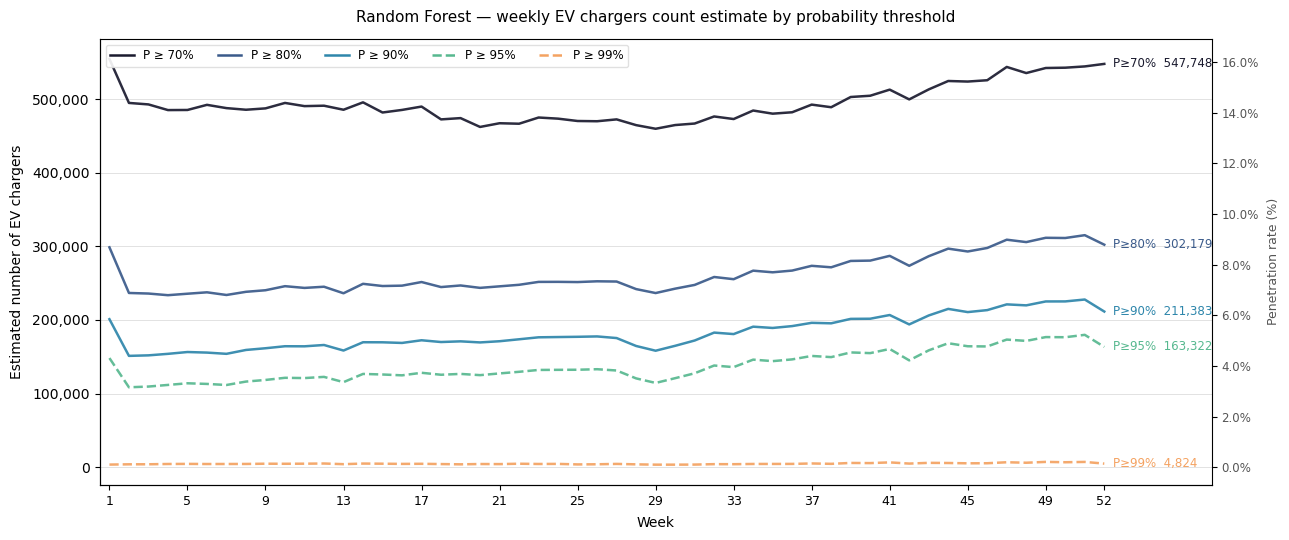

Saved → C:\Users\chris\OneDrive - Danmarks Tekniske Universitet\Documents\DTU\Thesis\Green Power and KONSTANT\MSc_thesis_github_repo\MSc-Thesis\results\ev_xgb_threshold_evolution.png


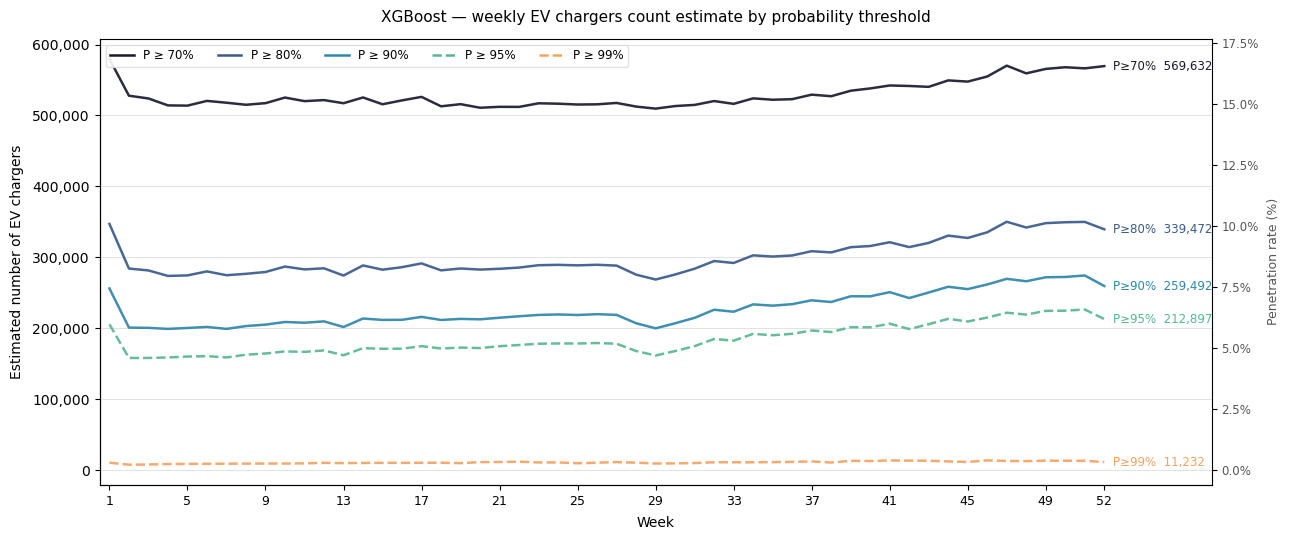

Done.


In [7]:
# ── 4. Demo ───────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import numpy as np

    

    fig = plot_threshold_evolution(
        df_rf,
        model_name="Random Forest",
        save_path= save_path_rf / "ev_rf_threshold_evolution.png",
        dpi=200,
    )
    plt.show()

    fig = plot_threshold_evolution(
    df_xgb,
    model_name="XGBoost",
    save_path= save_path_xgb / "ev_xgb_threshold_evolution.png",
    dpi=200,
    )
    plt.show()
    print("Done.")